# Adult Census Income

AIM: To compare the performance of Python and R in analysing the key factors in income inequality.

OBJECTIVES:
1. To develop logistic regression model in both Python and R language.
2. To explore and select important features to train the model in both Python and R.
3. To compare the evaluation metrics between Python and R.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [ ]:
#Load dataset
data = pd.read_csv('/content/adult.csv')

print("Initial Data Shape: ", data.shape)
data.info()

Initial Data Shape:  (32561, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
data.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


# Data Preprocessing

In [ ]:
#Replace all occurrences of "?" with NaN
data.replace('?', np.nan, inplace=True)

#Check missing values
print(data.isna().sum())

data = data.dropna()

#Impute missing values
for col in ['workclass', 'occupation', 'native.country']:
    data[col].fillna(data[col].mode()[0], inplace=True)

#Check missing values
print(data.isna().sum())

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64
age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64


<ipython-input-33-b7af7d195e2a>:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)
<ipython-input-33-b7af7d195e2a>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[col].fillna(data[col].mode()[0], inplace=True)


In [ ]:
#Check duplicates(before)
print('Duplicated rows (before):',data.duplicated().sum())

#Drop duplicates and reset index
data.drop_duplicates(keep='first', inplace=True)

#Check duplicates(after)
print('Duplicated rows (after):', data.duplicated().sum())

data.info()

Duplicated rows (before): 23
Duplicated rows (after): 0
<class 'pandas.core.frame.DataFrame'>
Index: 30139 entries, 1 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             30139 non-null  int64 
 1   workclass       30139 non-null  object
 2   fnlwgt          30139 non-null  int64 
 3   education       30139 non-null  object
 4   education.num   30139 non-null  int64 
 5   marital.status  30139 non-null  object
 6   occupation      30139 non-null  object
 7   relationship    30139 non-null  object
 8   race            30139 non-null  object
 9   sex             30139 non-null  object
 10  capital.gain    30139 non-null  int64 
 11  capital.loss    30139 non-null  int64 
 12  hours.per.week  30139 non-null  int64 
 13  native.country  30139 non-null  object
 14  income          30139 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


<ipython-input-34-1cb4754cbf0c>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop_duplicates(keep='first', inplace=True)


# EDA

In [ ]:
data_eda = data.copy()
bins = [0,25,35,45,55,65,100]
labels = ['0-25','25-35','35-45','45-55','55-65','65+']
data_eda['age_group'] = pd.cut(data_eda['age'], bins=bins, labels=labels)

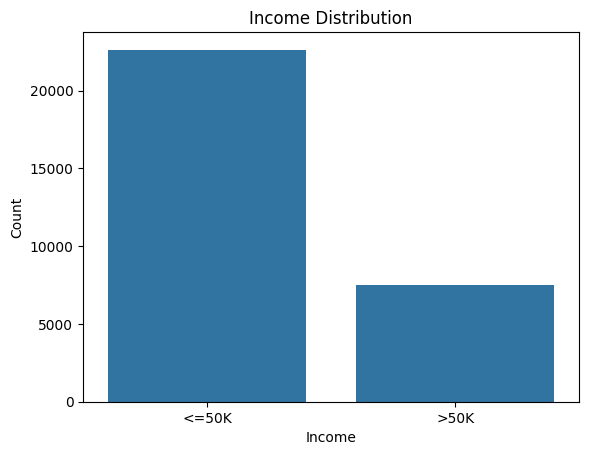

In [ ]:
sns.countplot(x='income', data=data_eda)
plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Count')
plt.show()

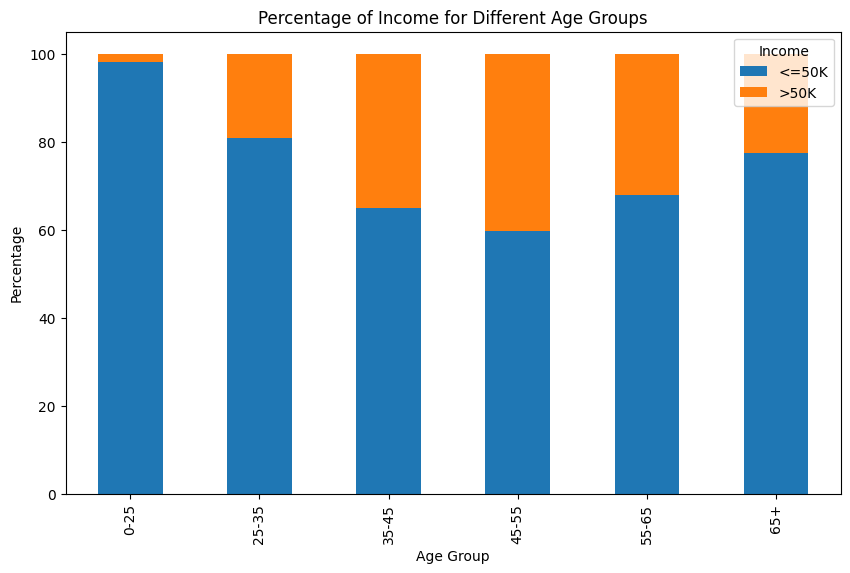

In [ ]:
age_income_ratio = pd.crosstab(data_eda['age_group'], data_eda['income'], normalize='index') * 100
age_income_ratio.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Percentage of Income for Different Age Groups')
plt.ylabel('Percentage')
plt.xlabel('Age Group')
plt.legend(title='Income')
plt.show()

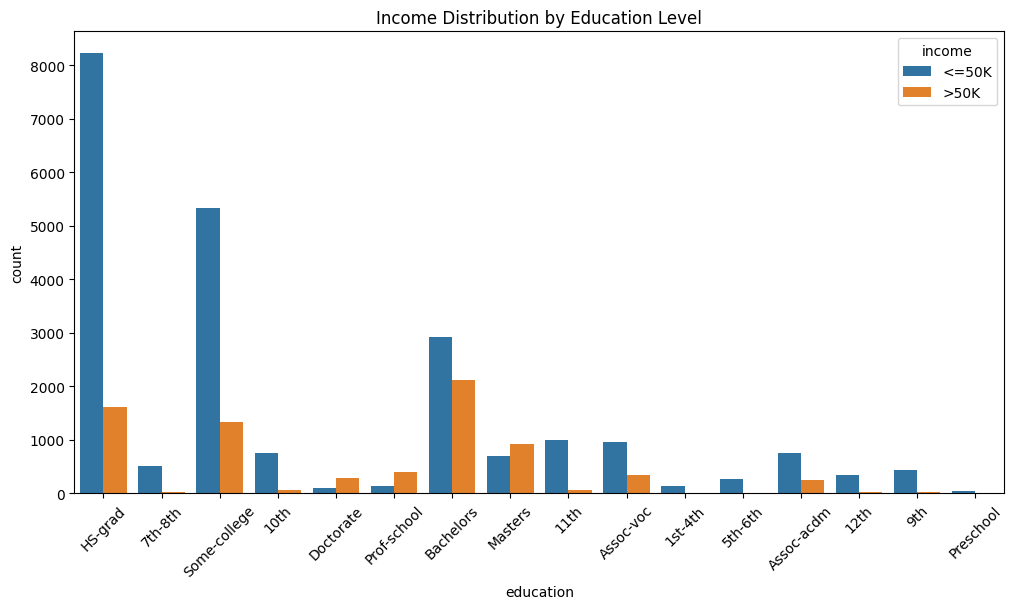

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x="education", hue="income", data=data_eda)
plt.xticks(rotation=45)
plt.title("Income Distribution by Education Level")
plt.show()

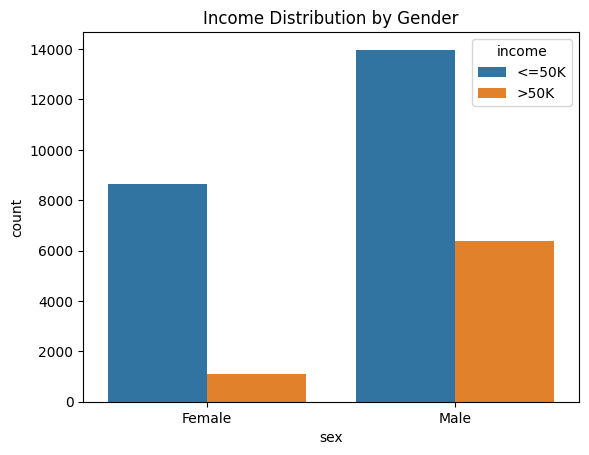

In [ ]:
sns.countplot(x="sex", hue="income", data=data_eda)
plt.title("Income Distribution by Gender")
plt.show()

# Data Preprocessing

In [ ]:
data_model = data.copy()

In [ ]:
# Define features
num_features = ['age', 'education.num', 'hours.per.week', 'capital.gain', 'capital.loss']
cat_features = ['workclass', 'marital.status', 'relationship', 'sex']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first'), cat_features)
    ])

# Feature Selection and Build Logistic Regression Model

In [ ]:
# Create full pipeline with feature selection
model = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selector', SelectKBest(mutual_info_classif, k=10)),  # Select top 10 features
    ('classifier', LogisticRegression(max_iter=1000))
])

#Train-test split
X = data[num_features + cat_features]
y = data['income'].map({'<=50K': 0, '>50K': 1})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'education.num',
                                                   'hours.per.week',
                                                   'capital.gain',
                                                   'capital.loss']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['workclass',
                                                   'marital.status',
                                                   'relationship', 'sex'])])),
                ('feature_selector',
                 SelectKBest(score_func=<function mutual_info_classif at 0x7c62016737e0>)),
                ('classifier', LogisticRegression(max_iter=1000))])

In [ ]:
# Get feature names after preprocessing
preprocessor.fit(X_train)
feature_names = (num_features +
                list(model.named_steps['preprocessor']
                    .named_transformers_['cat']
                    .get_feature_names_out(cat_features)))

# Get selected feature mask
selected_mask = model.named_steps['feature_selector'].get_support()
selected_features = [f for f, m in zip(feature_names, selected_mask) if m]
print("Selected Features:", selected_features)

Selected Features: ['age', 'education.num', 'hours.per.week', 'capital.gain', 'capital.loss', 'marital.status_Married-civ-spouse', 'marital.status_Never-married', 'relationship_Not-in-family', 'relationship_Own-child', 'sex_Male']


# Evaluation


Cross-validation scores: [0.83537217 0.83907092 0.84404811 0.82621319 0.83907092]
Mean CV accuracy: 0.8368

Logistic Regression
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      4580
           1       0.72      0.57      0.64      1448

    accuracy                           0.84      6028
   macro avg       0.80      0.75      0.77      6028
weighted avg       0.84      0.84      0.84      6028

[[4254  326]
 [ 620  828]]
Accuracy: 0.8431
Precision: 0.7175
Recall: 0.5718
F1-score: 0.6364

Feature Importance:
                              feature  importance
5  marital.status_Married-civ-spouse    2.275348
3                       capital.gain    2.264802
1                      education.num    0.926024
7         relationship_Not-in-family    0.357045
2                     hours.per.week    0.338792
0                                age    0.317872
4                       capital.loss    0.276451
9                           sex_Male

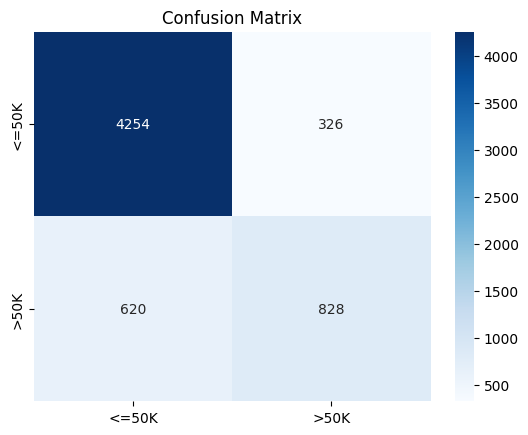

In [ ]:
# Cross-validation
cv_scores = cross_val_score(model, X_train, y_train, cv=5)
print(f"\nCross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")

# Predictions and evaluation
y_pred = model.predict(X_test)
print('\nLogistic Regression')
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall: {recall_score(y_test, y_pred):.4f}')
print(f'F1-score: {f1_score(y_test, y_pred):.4f}')

# Feature importance
if hasattr(model.named_steps['classifier'], 'coef_'):
    importance = pd.DataFrame({
        'feature': selected_features,
        'importance': model.named_steps['classifier'].coef_[0]
    }).sort_values('importance', ascending=False)
    print("\nFeature Importance:\n", importance)

# Confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d',
            cmap='Blues',
            xticklabels=['<=50K', '>50K'],
            yticklabels=['<=50K', '>50K'])
plt.title('Confusion Matrix')
plt.show()